In [27]:
%load_ext autoreload
%autoreload 2
import h5py 
import scipy 
import numpy as np 
import matplotlib.pyplot as plt 
from comborun.base  import ComboRun, exclusion_pc
from run_ranges import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


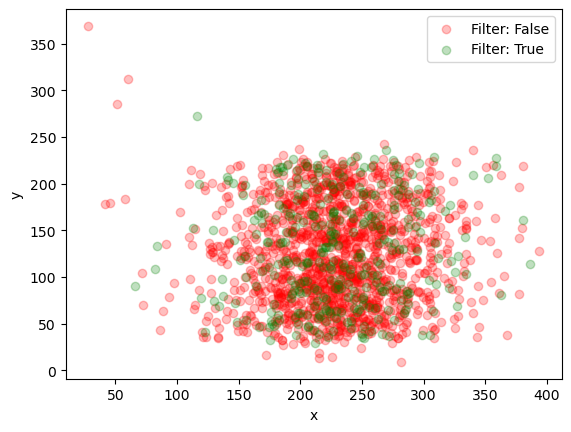

In [28]:
ps20nm15 = ComboRun(generate_filenames(ps20, 15, let='d'))
ps20nm5 = ComboRun(generate_filenames(ps20, 5, let='d'))
ps20nm15.filter_focused(ps20nm5)
ps20nm15.scatter_xy()

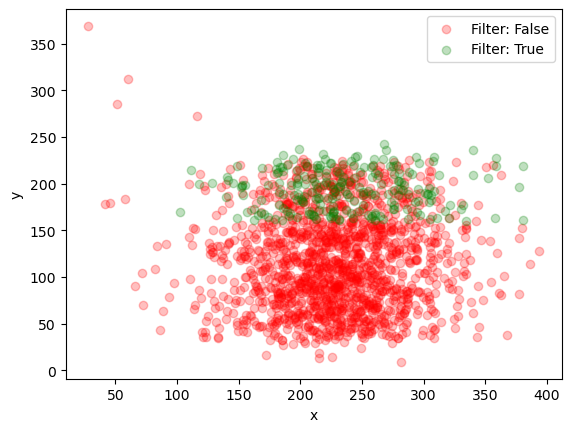

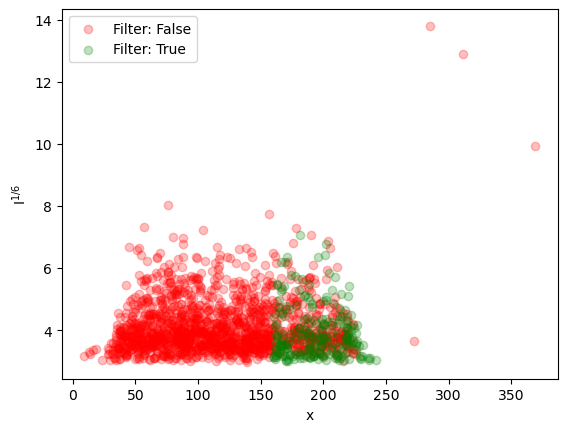

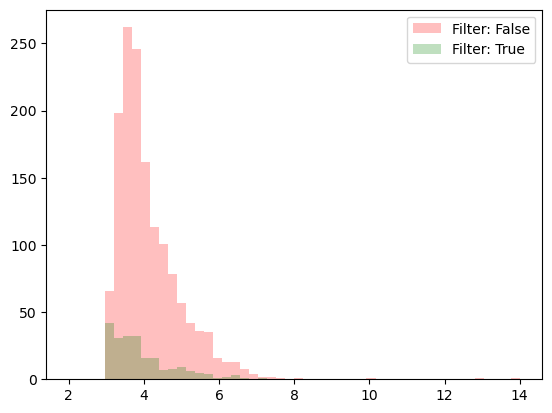

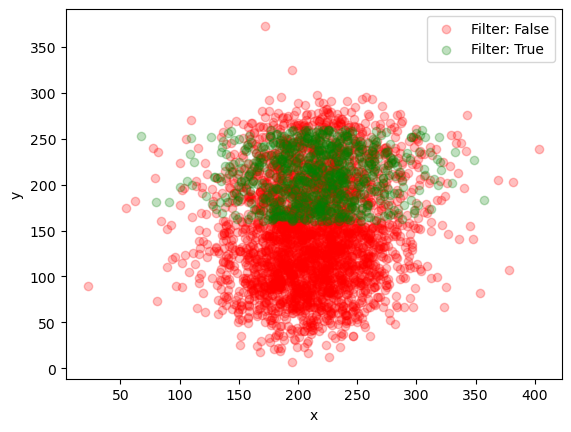

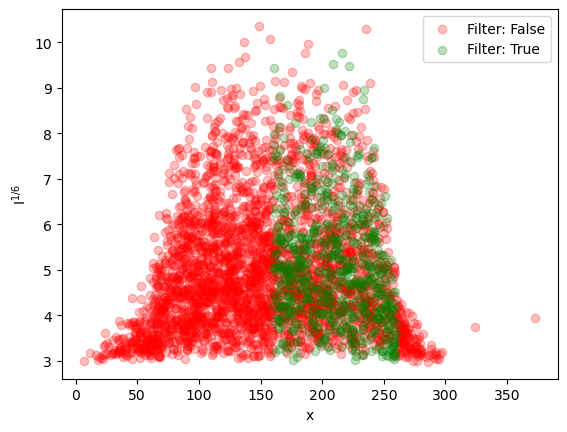

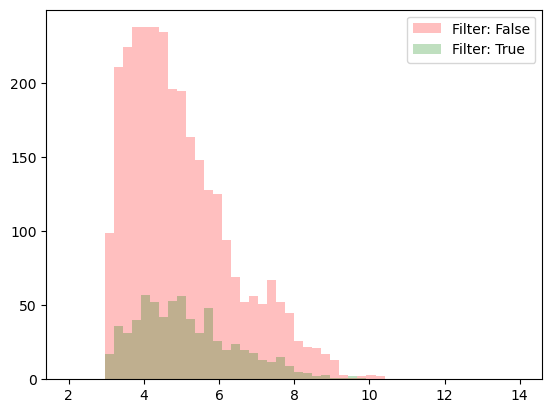

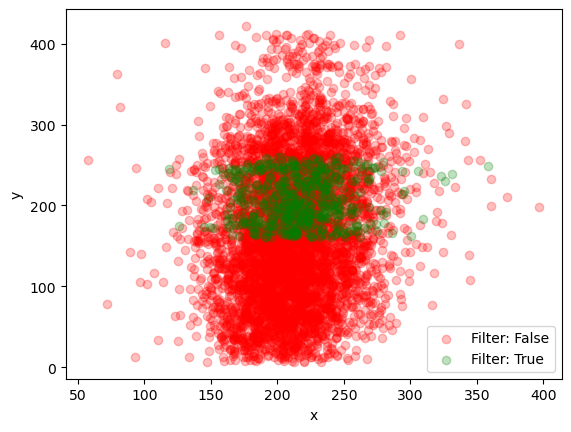

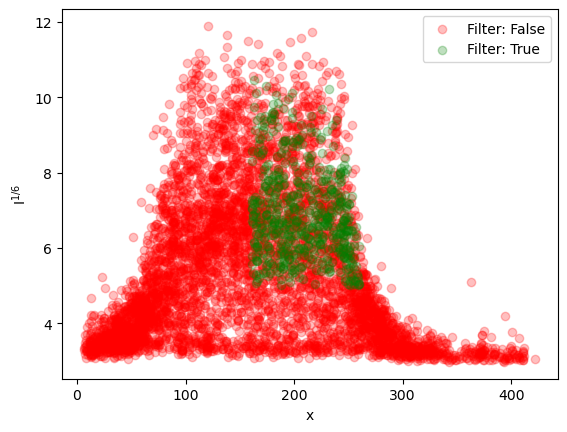

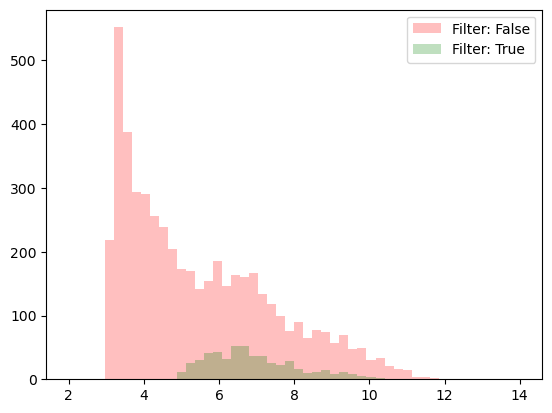

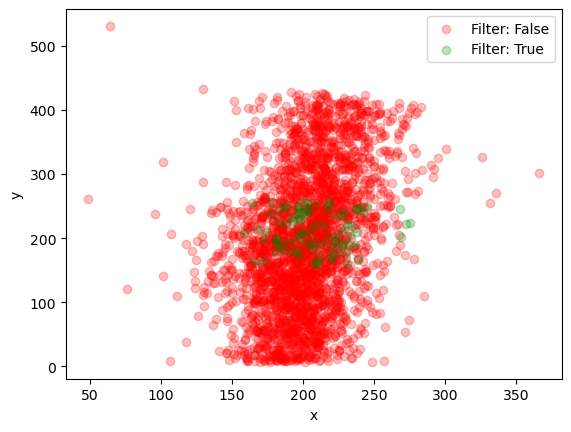

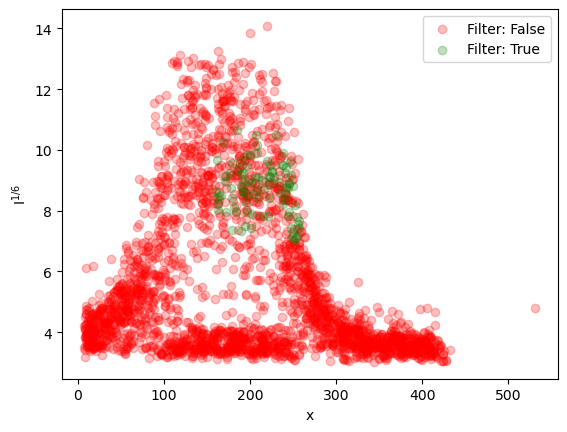

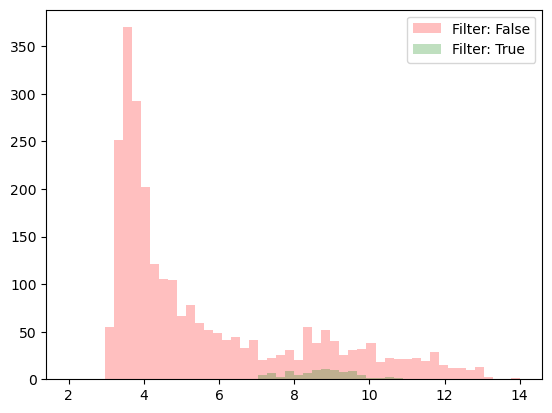

In [29]:



ps20nm15 = ComboRun(generate_filenames(ps20, 15, let='d'))
ps20nm5 = ComboRun(generate_filenames(ps20, 5, let='d'))
ps20nm15.filter_focused(ps20nm5, focus_threshold=0.85)
ps20nm15.filter_y(160, 260)
ps20nm15.filter_i(3)
ps20nm15.scatter_xy()
ps20nm15.scatter_yi()
ps20nm15.hist_i(range=(2,14))

ps30nm15 = ComboRun(generate_filenames(ps30, 15, let='d'))
ps30nm5 = ComboRun(generate_filenames(ps30, 5, let='d'))
ps30nm15.filter_focused(ps30nm5, focus_threshold=0.85)
ps30nm15.filter_y(160, 260)
ps30nm15.filter_i(3)
ps30nm15.scatter_xy()
ps30nm15.scatter_yi()
ps30nm15.hist_i(range=(2,14))

ps40nm15 = ComboRun(generate_filenames(ps40, 15, let='d'))
ps40nm5 = ComboRun(generate_filenames(ps40, 5, let='d'))
ps40nm15.filter_focused(ps40nm5, focus_threshold=0.85)
ps40nm15.filter_y(160, 260)
ps40nm15.filter_i(5)
ps40nm15.scatter_xy()
ps40nm15.scatter_yi()
ps40nm15.hist_i(range=(2,14))

ps50nm15 = ComboRun(generate_filenames(ps50, 15, let='d'))
ps50nm5 = ComboRun(generate_filenames(ps50, 5, let='d'))
ps50nm15.filter_focused(ps50nm5, focus_threshold=0.85)
ps50nm15.filter_y(160, 260)
ps50nm15.filter_i(7)
ps50nm15.scatter_xy()
ps50nm15.scatter_yi()
ps50nm15.hist_i(range=(2,14))


Linear fit: 0.16928223279805032*m+0.09729114164699382


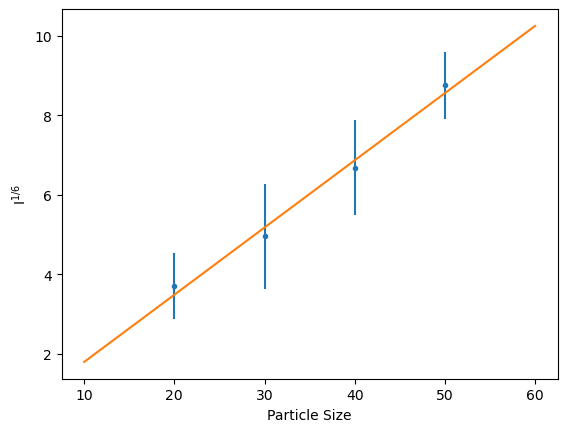

In [30]:

inten_med = [
np.median(ps20nm15.peak_is[ps20nm15.filter]**(1/6)),
np.median(ps30nm15.peak_is[ps30nm15.filter]**(1/6)),
np.median(ps40nm15.peak_is[ps40nm15.filter]**(1/6)),
np.median(ps50nm15.peak_is[ps50nm15.filter]**(1/6)),
]

inten_err = [
np.std(ps20nm15.peak_is[ps20nm15.filter]**(1/6)),
np.std(ps30nm15.peak_is[ps30nm15.filter]**(1/6)),
np.std(ps40nm15.peak_is[ps40nm15.filter]**(1/6)),
np.std(ps50nm15.peak_is[ps50nm15.filter]**(1/6)),
]

ps_size = np.array([20, 30, 40, 50])
#ps_size = np.array([23, 31, 41, 51])
popt1, pcov1 = scipy.optimize.curve_fit(lambda x,m,c: m*x+c, ps_size, inten_med)
cov_m_m = pcov1[0,0]
cov_c_c = pcov1[1,1]
cov_m_c = pcov1[0,1]
# Error propagation
sigma_y = np.sqrt(
    (ps_size**2)*cov_m_m +
    cov_c_c +
    2*ps_size*cov_m_c
)


plt.figure()
x = np.linspace(10, 60)
plt.errorbar(x=ps_size, y=inten_med, yerr=inten_err, marker='.', ls='None', label='data')
plt.plot(x, popt1[0]*x+popt1[1],label='fit')
plt.xlabel('Particle Size')
plt.ylabel('I$^{1/6}$')

print(f'Linear fit: {popt1[0]}*m+{popt1[1]}')

#Linear fit summary:
#------------------------------------------------------
#slope: 0.15585869242332118
#offset: 0.07436668870208166
#without forcing curve to go through zero
#error: [0.01176697 0.44698987]
#------------------------------------------------------
